In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score

In [2]:
# Load the dataset
data = pd.read_csv("heart.csv")

# Display the first few rows
print(data.head())

# Check for missing values
print(data.isnull().sum())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [4]:
# Convert categorical variables to numerical using Label Encoding
label_encoder = LabelEncoder()
categorical_columns = data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col])

In [7]:
# Handle missing values (if any)
# Check for missing values
if data.isnull().sum().any():
    print("Warning: Missing values found in the dataset. Imputing with the mean.")
    imputer = SimpleImputer(strategy='mean')  # Use 'mean', 'median', or 'most_frequent'
    data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)  # Impute and convert back to DataFrame

In [8]:
#Separate features (X) and target (y)
X = data.drop(columns=['target'])  # Assuming 'target' is the column you want to predict
y = data['target']

In [9]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # You can change the test size and random state


In [10]:
# 5. Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
#LOGISTIC REGRESSION

In [11]:
# 6. Train the Logistic Regression model
model = LogisticRegression(max_iter=1000)  # Increase max_iter if needed
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# 7. Make predictions on the test set
y_pred = model.predict(X_test)


In [17]:
# 8. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [18]:
# 9. Print the results
print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.8524590163934426
Recall: 0.84375
F1-score: 0.8571428571428571


In [19]:
# --- Optional: Print classification report for more detailed metrics ---
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

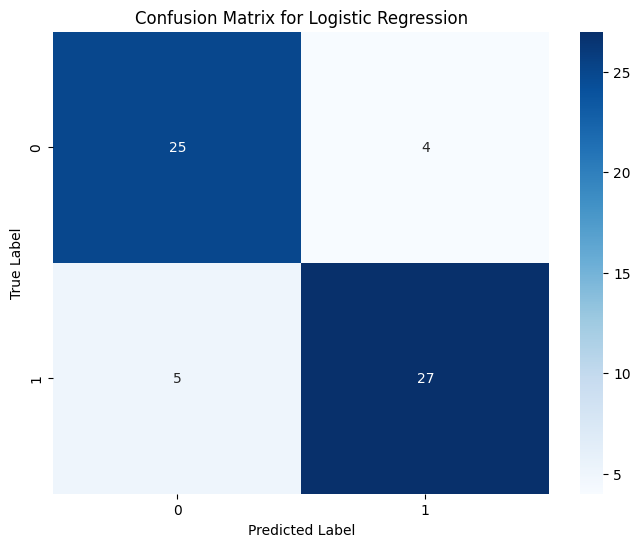

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn

# ... (rest of your code: data loading, model training, etc.) ...

# Plotting the Confusion Matrix
def plot_confusion_matrix(y_test, y_pred, title):
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

plot_confusion_matrix(y_test, y_pred, "Confusion Matrix for Logistic Regression")

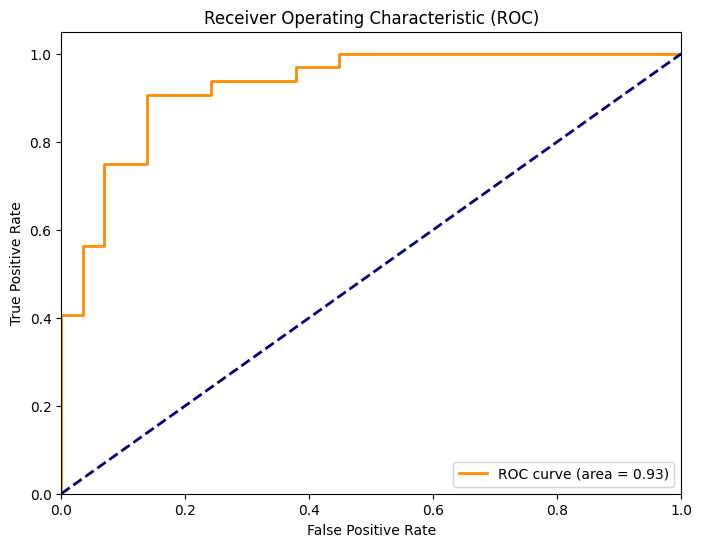

In [34]:
#Example of ROC Curve (Optional, but very informative)
from sklearn.metrics import roc_curve, auc

y_probs = model.predict_proba(X_test)[:, 1] # Get the probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier

# ... (rest of your code: data loading, model training, etc.) ...

# Train the Random Forest model
model = RandomForestClassifier(random_state=42)  # You can adjust hyperparameters here (e.g., n_estimators, max_depth)
model.fit(X_train, y_train)

# ... (rest of your code: making predictions, evaluating the model, etc.) ...

RandomForestClassifier(random_state=42)

In [37]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [40]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")


Accuracy: 0.8360655737704918
Recall: 0.84375
F1-score: 0.84375


In [41]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

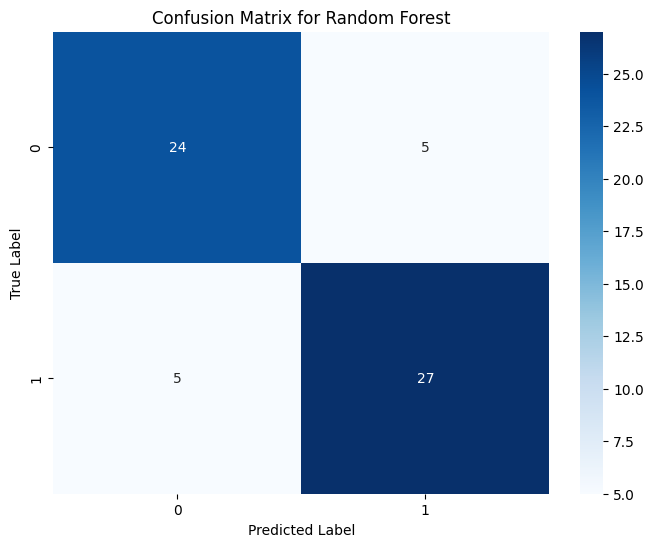

In [42]:
# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))  # Use y_test for labels
plt.title("Confusion Matrix for Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


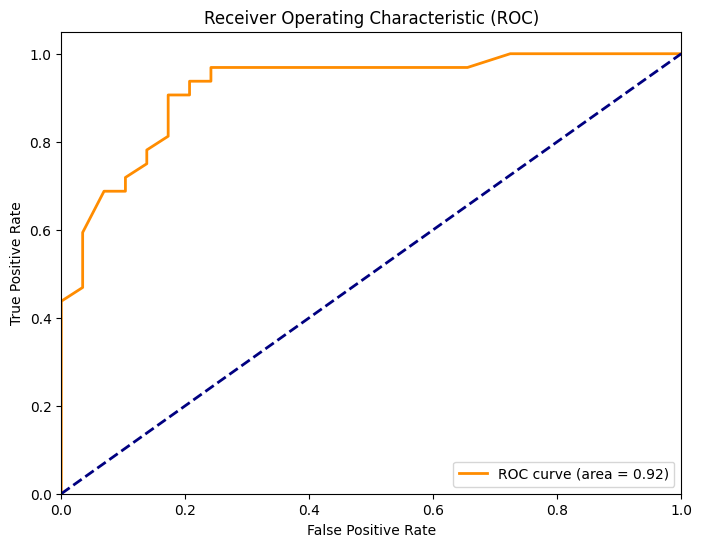

In [43]:
# ROC Curve and AUC
y_probs = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [44]:
#Naive Bias

In [45]:
# Train the Gaussian Naive Bayes model (assuming your features are continuous)
model = GaussianNB()  # If you have categorical features, use a different Naive Bayes variant (e.g., MultinomialNB, CategoricalNB)
model.fit(X_train, y_train)

GaussianNB()

In [46]:
# Make predictions
y_pred = model.predict(X_test)

In [47]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.8688524590163934
Recall: 0.84375
F1-score: 0.8709677419354839


In [48]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)


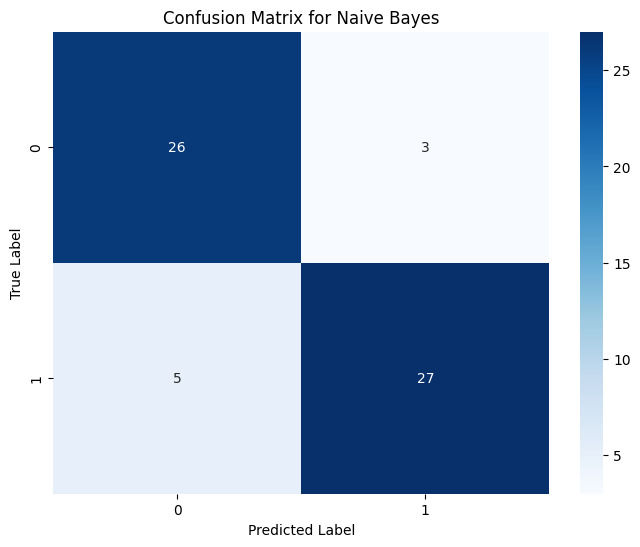

In [49]:
# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix for Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

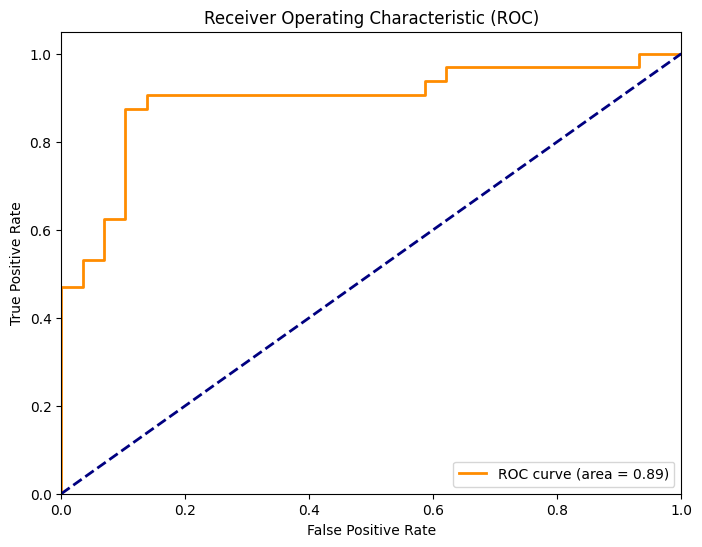

In [50]:
# ROC Curve and AUC (for binary classification)
y_probs = model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#SVM MODEL

In [51]:
# Train the SVM model
model = SVC(random_state=42, probability=True)  # probability=True is needed for ROC/AUC
model.fit(X_train, y_train)


SVC(probability=True, random_state=42)

In [52]:
# Make predictions
y_pred = model.predict(X_test)


In [53]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.8688524590163934
Recall: 0.84375
F1-score: 0.8709677419354839


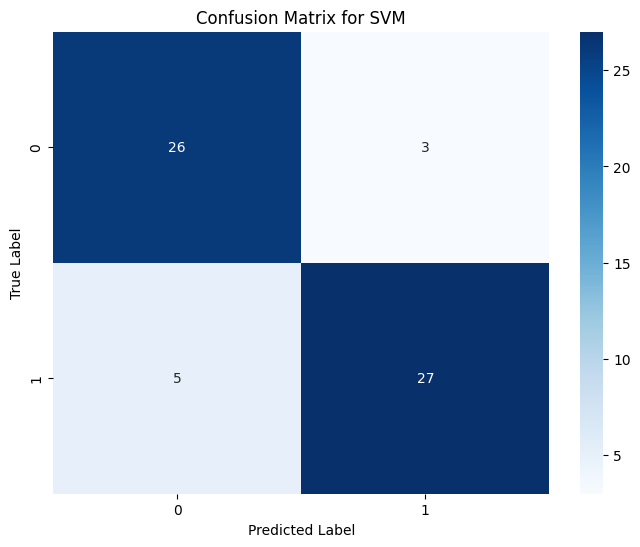

In [54]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix for SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

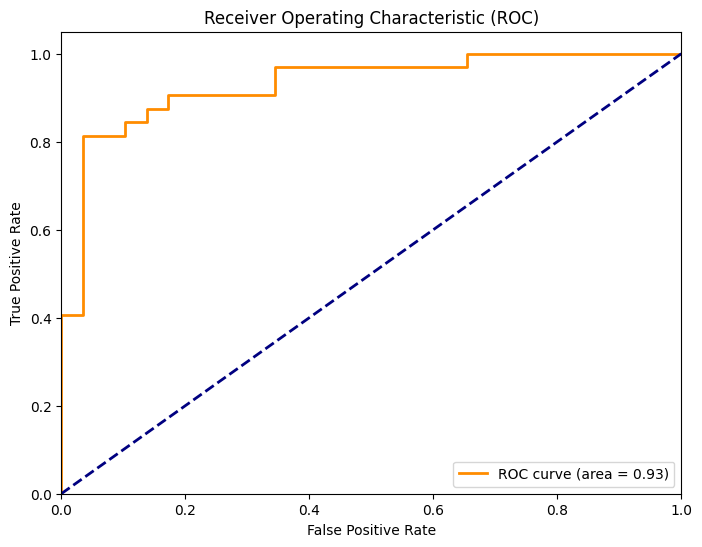

In [55]:
# ROC Curve and AUC (for binary classification)
y_probs = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#Descision Tree

In [57]:
from sklearn.tree import DecisionTreeClassifier  # Import DecisionTreeClassifier

# ... (rest of your code: data loading, model training, etc.) ...

# Train the Decision Tree model
model = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters here (e.g., max_depth, min_samples_split)
model.fit(X_train, y_train)

# ... (rest of your code: making predictions, evaluating the model, etc.) ...

DecisionTreeClassifier(random_state=42)

In [58]:
# Make predictions
y_pred = model.predict(X_test)

In [59]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.7540983606557377
Recall: 0.65625
F1-score: 0.7368421052631579


In [60]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

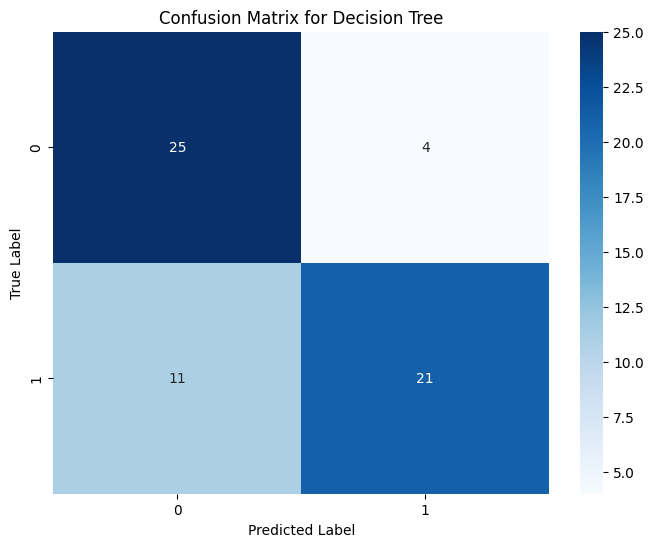

In [62]:
# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Confusion Matrix for Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

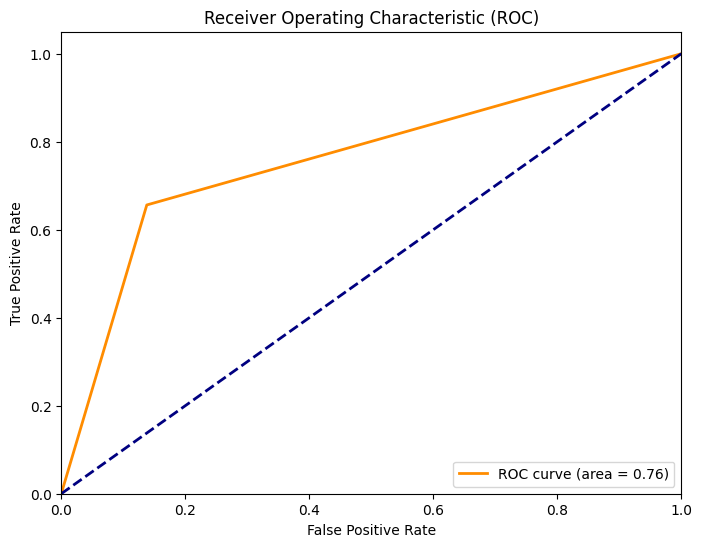

In [63]:
# ROC Curve and AUC (for binary classification)
y_probs = model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#Comparison

Comparison of Algorithm Performance:
Logistic Regression: Accuracy = 0.8525, Recall = 0.8438, F1-score = 0.8571
Random Forest: Accuracy = 0.8361, Recall = 0.8438, F1-score = 0.8438
Decision Tree: Accuracy = 0.7541, Recall = 0.6562, F1-score = 0.7368
Naive Bayes: Accuracy = 0.8689, Recall = 0.8438, F1-score = 0.8710
SVM: Accuracy = 0.8689, Recall = 0.8438, F1-score = 0.8710


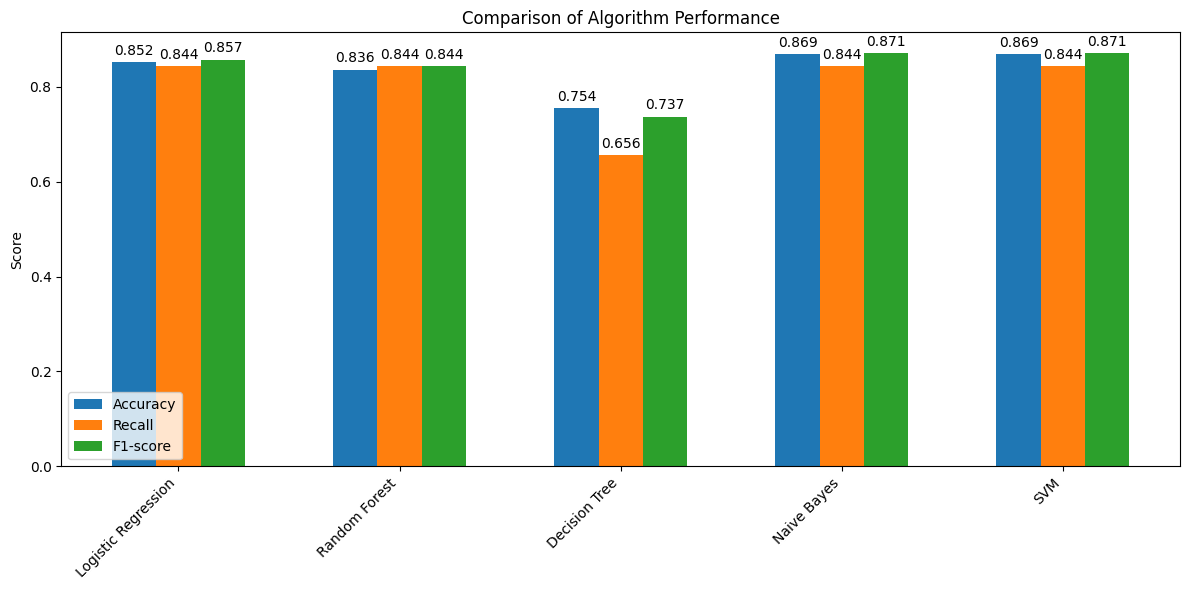

In [64]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (replace 'heart.csv' with the actual path if needed)
try:
    data = pd.read_csv("heart.csv")
except FileNotFoundError:
    print("Error: heart.csv not found. Please ensure the file is in the correct directory.")
    exit()

# Handle missing values (if any) - Example: filling with the mean
for col in data.columns:
    if data[col].isnull().any():
        data[col].fillna(data[col].mean(), inplace=True)

# Separate features (X) and target (y)
X = data.drop(columns=['target'])  # Replace 'target' with your actual target column name
y = data['target']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (important for some algorithms like Logistic Regression and SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Dictionary to store results
results = {}

# 1. Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')  # Increased max_iter if needed
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results['Logistic Regression'] = accuracy_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)

# 2. Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)

# 3. Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results['Decision Tree'] = accuracy_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)

# 4. Naive Bayes (Gaussian)
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results['Naive Bayes'] = accuracy_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)

# 5. SVM
model = SVC(random_state=42, probability=True) # probability=True is needed for ROC/AUC if you want to add it later
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
results['SVM'] = accuracy_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred)

# Print and plot the results
model_names = list(results.keys())
accuracies = [res[0] for res in results.values()]
recalls = [res[1] for res in results.values()]
f1_scores = [res[2] for res in results.values()]

print("Comparison of Algorithm Performance:")
for name, (acc, rec, f1) in results.items():
    print(f"{name}: Accuracy = {acc:.4f}, Recall = {rec:.4f}, F1-score = {f1:.4f}")


# Plotting the results (Bar chart)
x = np.arange(len(model_names))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, accuracies, width, label='Accuracy')
rects2 = ax.bar(x, recalls, width, label='Recall')
rects3 = ax.bar(x + width, f1_scores, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Comparison of Algorithm Performance')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')  # Rotate labels for better readability
ax.legend()


def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height.round(3)),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()

plt.show()